# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [2]:
df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')

# EDA

In [3]:
print("Info Dataset:")
print(df.info())
print("\nStatistik Dasar:")
df.describe()

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


Distribusi Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Persentase:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


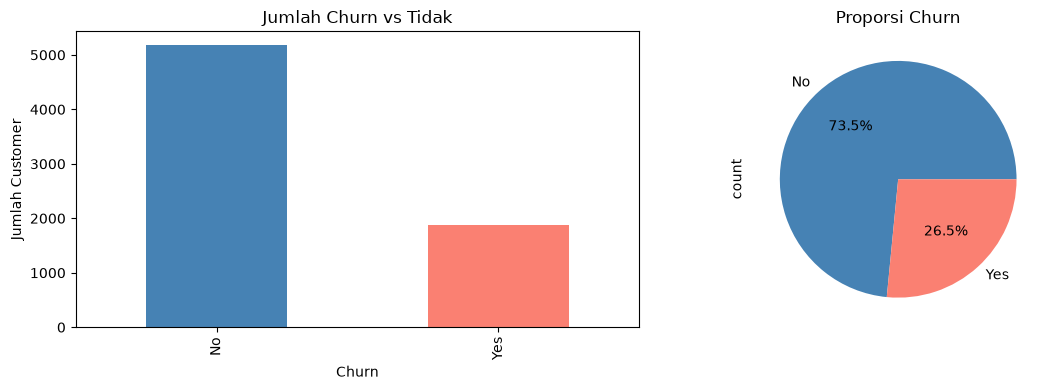

In [5]:
churn_count = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Distribusi Churn:")
print(churn_count)
print("\nPersentase:")
print(churn_pct.round(2))

# Visualisasi
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
churn_count.plot(kind='bar', ax=ax[0], color=['steelblue', 'salmon'])
ax[0].set_title('Jumlah Churn vs Tidak')
ax[0].set_xlabel('Churn')
ax[0].set_ylabel('Jumlah Customer')

# Pie chart
churn_count.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', 
                 colors=['steelblue', 'salmon'])
ax[1].set_title('Proporsi Churn')

plt.tight_layout()
plt.savefig('../figures/churn_distribution.png', dpi=150)
plt.show()

In [6]:
# Cek kenapa TotalCharges jadi object
print(df['TotalCharges'].unique()[:20])

# Fix: convert ke numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Cek missing values setelah convert
print("\nMissing TotalCharges:", df['TotalCharges'].isnull().sum())

# Lihat row yang bermasalah
print(df[df['TotalCharges'].isnull()])

['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']

Missing TotalCharges: 11
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE 

In [7]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [8]:
# Pisahkan kolom kategorikal dan numerikal
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('customerID')  # hapus ID, tidak relevan

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("=" * 50)
print("CATEGORICAL FEATURES - UNIQUE VALUES")
print("=" * 50)

for col in categorical_cols:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].value_counts().to_string())
    print("-" * 30)

CATEGORICAL FEATURES - UNIQUE VALUES

gender (2 unique):
gender
Male      3555
Female    3488
------------------------------

Partner (2 unique):
Partner
No     3641
Yes    3402
------------------------------

Dependents (2 unique):
Dependents
No     4933
Yes    2110
------------------------------

PhoneService (2 unique):
PhoneService
Yes    6361
No      682
------------------------------

MultipleLines (3 unique):
MultipleLines
No                  3390
Yes                 2971
No phone service     682
------------------------------

InternetService (3 unique):
InternetService
Fiber optic    3096
DSL            2421
No             1526
------------------------------

OnlineSecurity (3 unique):
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
------------------------------

OnlineBackup (3 unique):
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
------------------------------

DeviceProte

In [9]:
df.duplicated().sum()

0

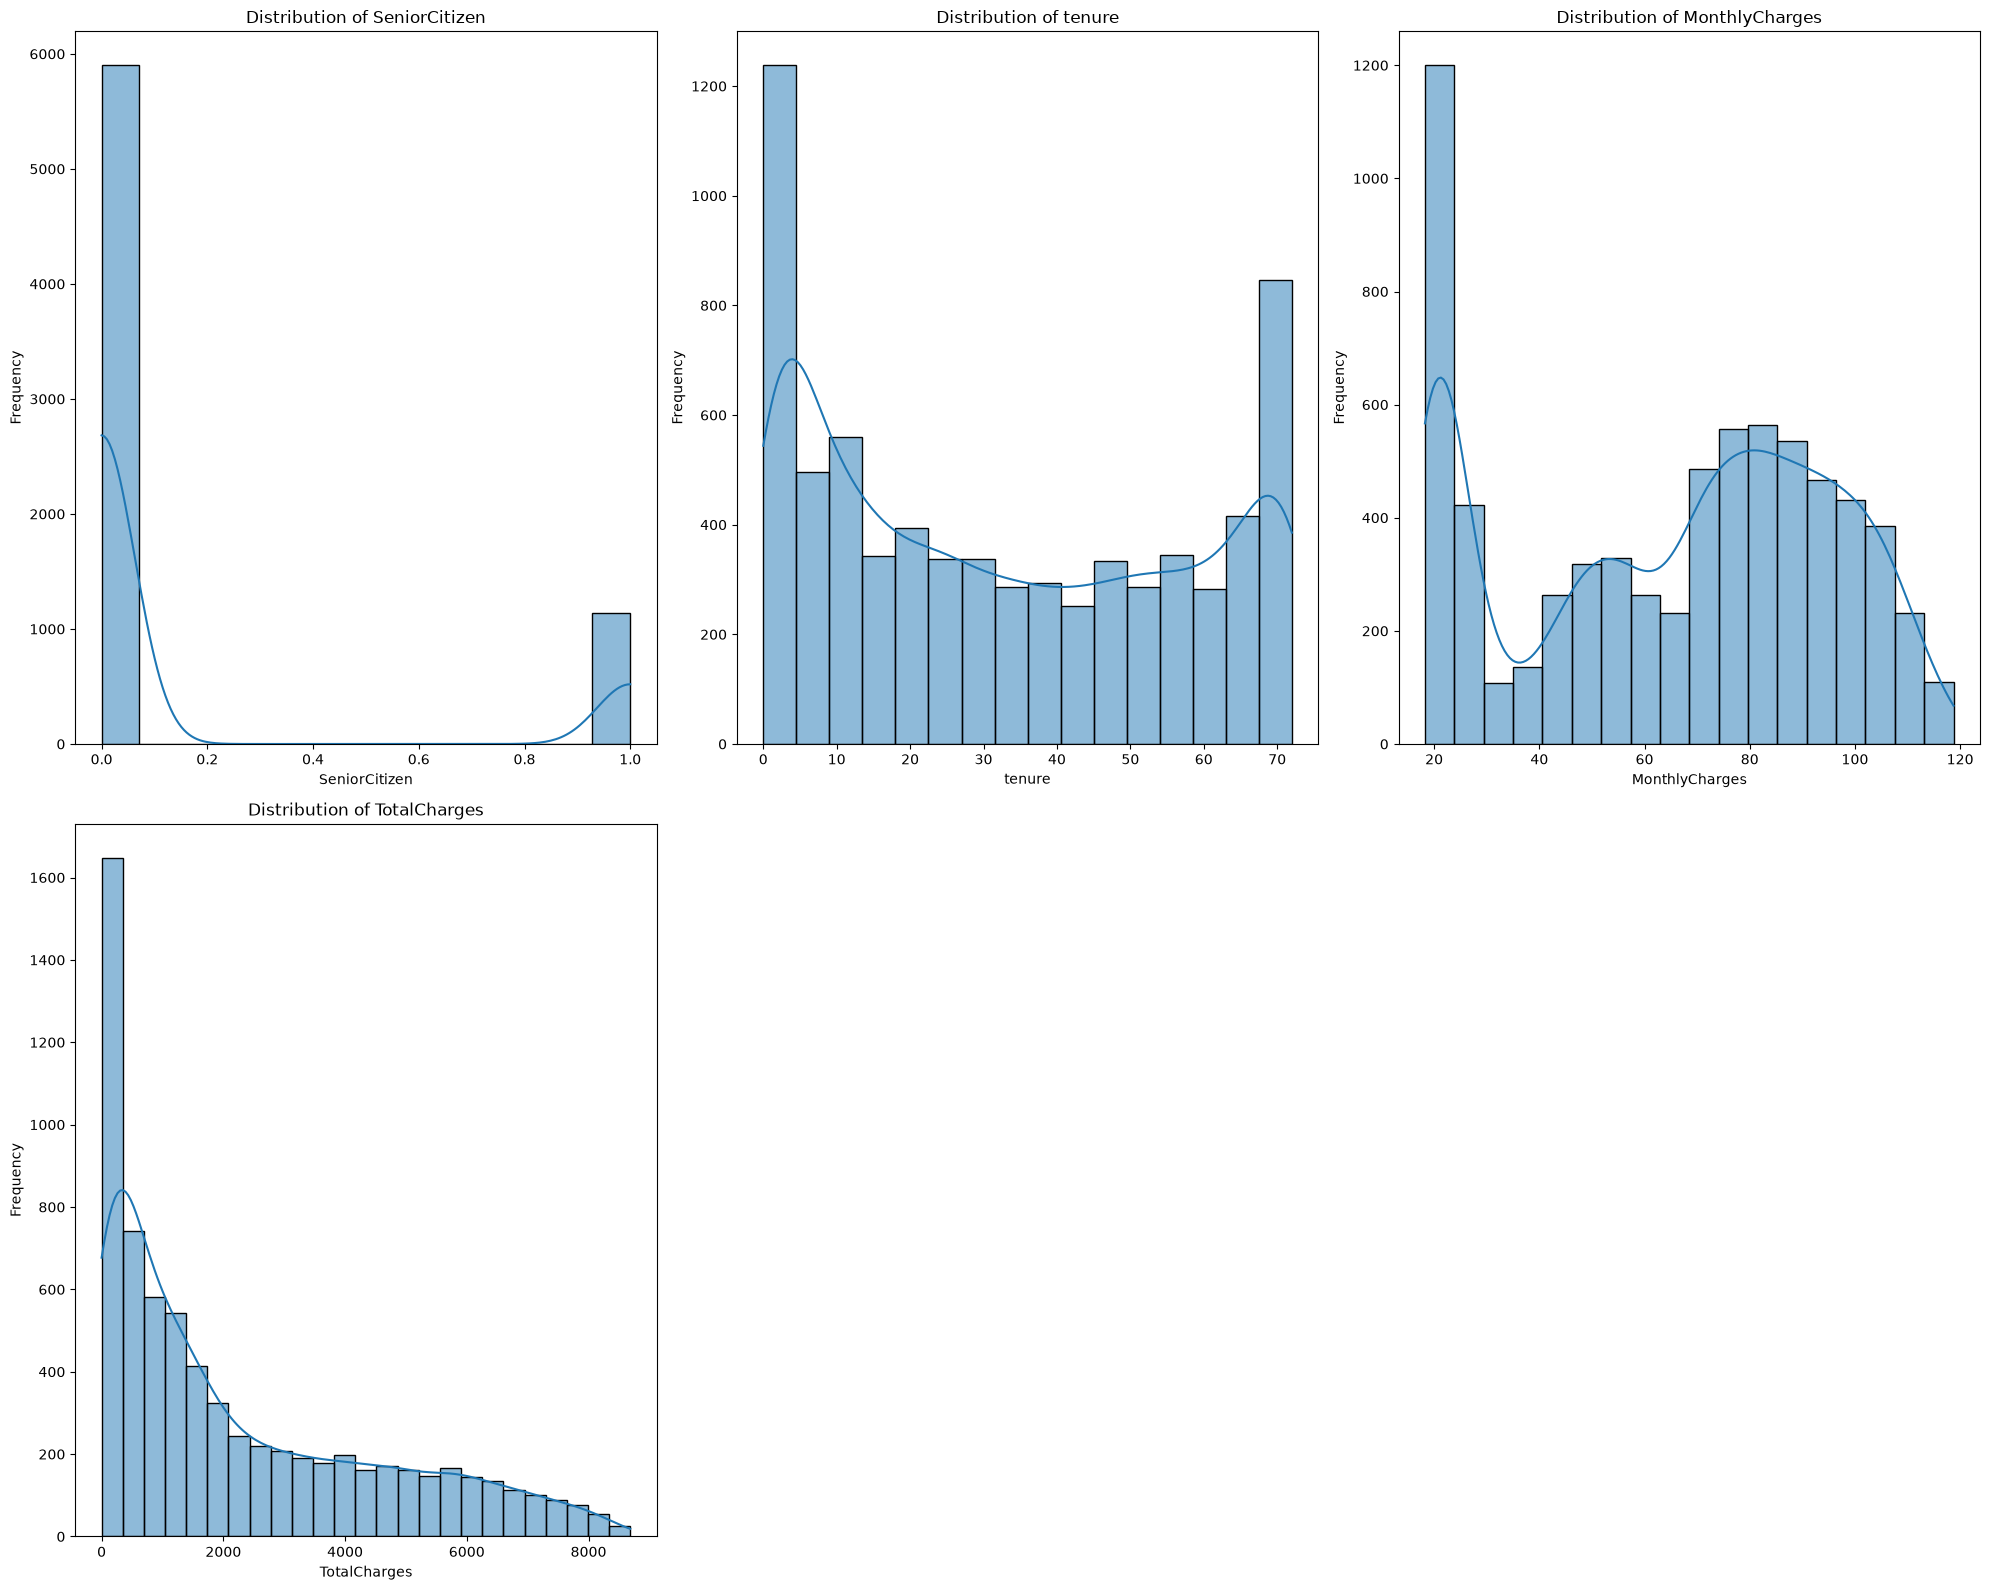

In [10]:
numerical_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(20, 16))

for i, col in enumerate(numerical_cols):
    plt.subplot((len(numerical_cols)+2)//3, 3, i+1)

    sns.histplot(df[col].dropna(), kde=True)

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('../figures/numerical_distribution.png', dpi=150)
plt.show()

# 🔍 Churn Rate per Fitur Kategorikal

Sampai sini kita baru lihat *jumlah* tiap kategori. Sekarang pertanyaan bisnis sebenarnya: **kategori mana yang paling sering churn?** Kita hitung % churn di dalam tiap kategori dan bandingkan dengan rata-rata keseluruhan (26.5%).

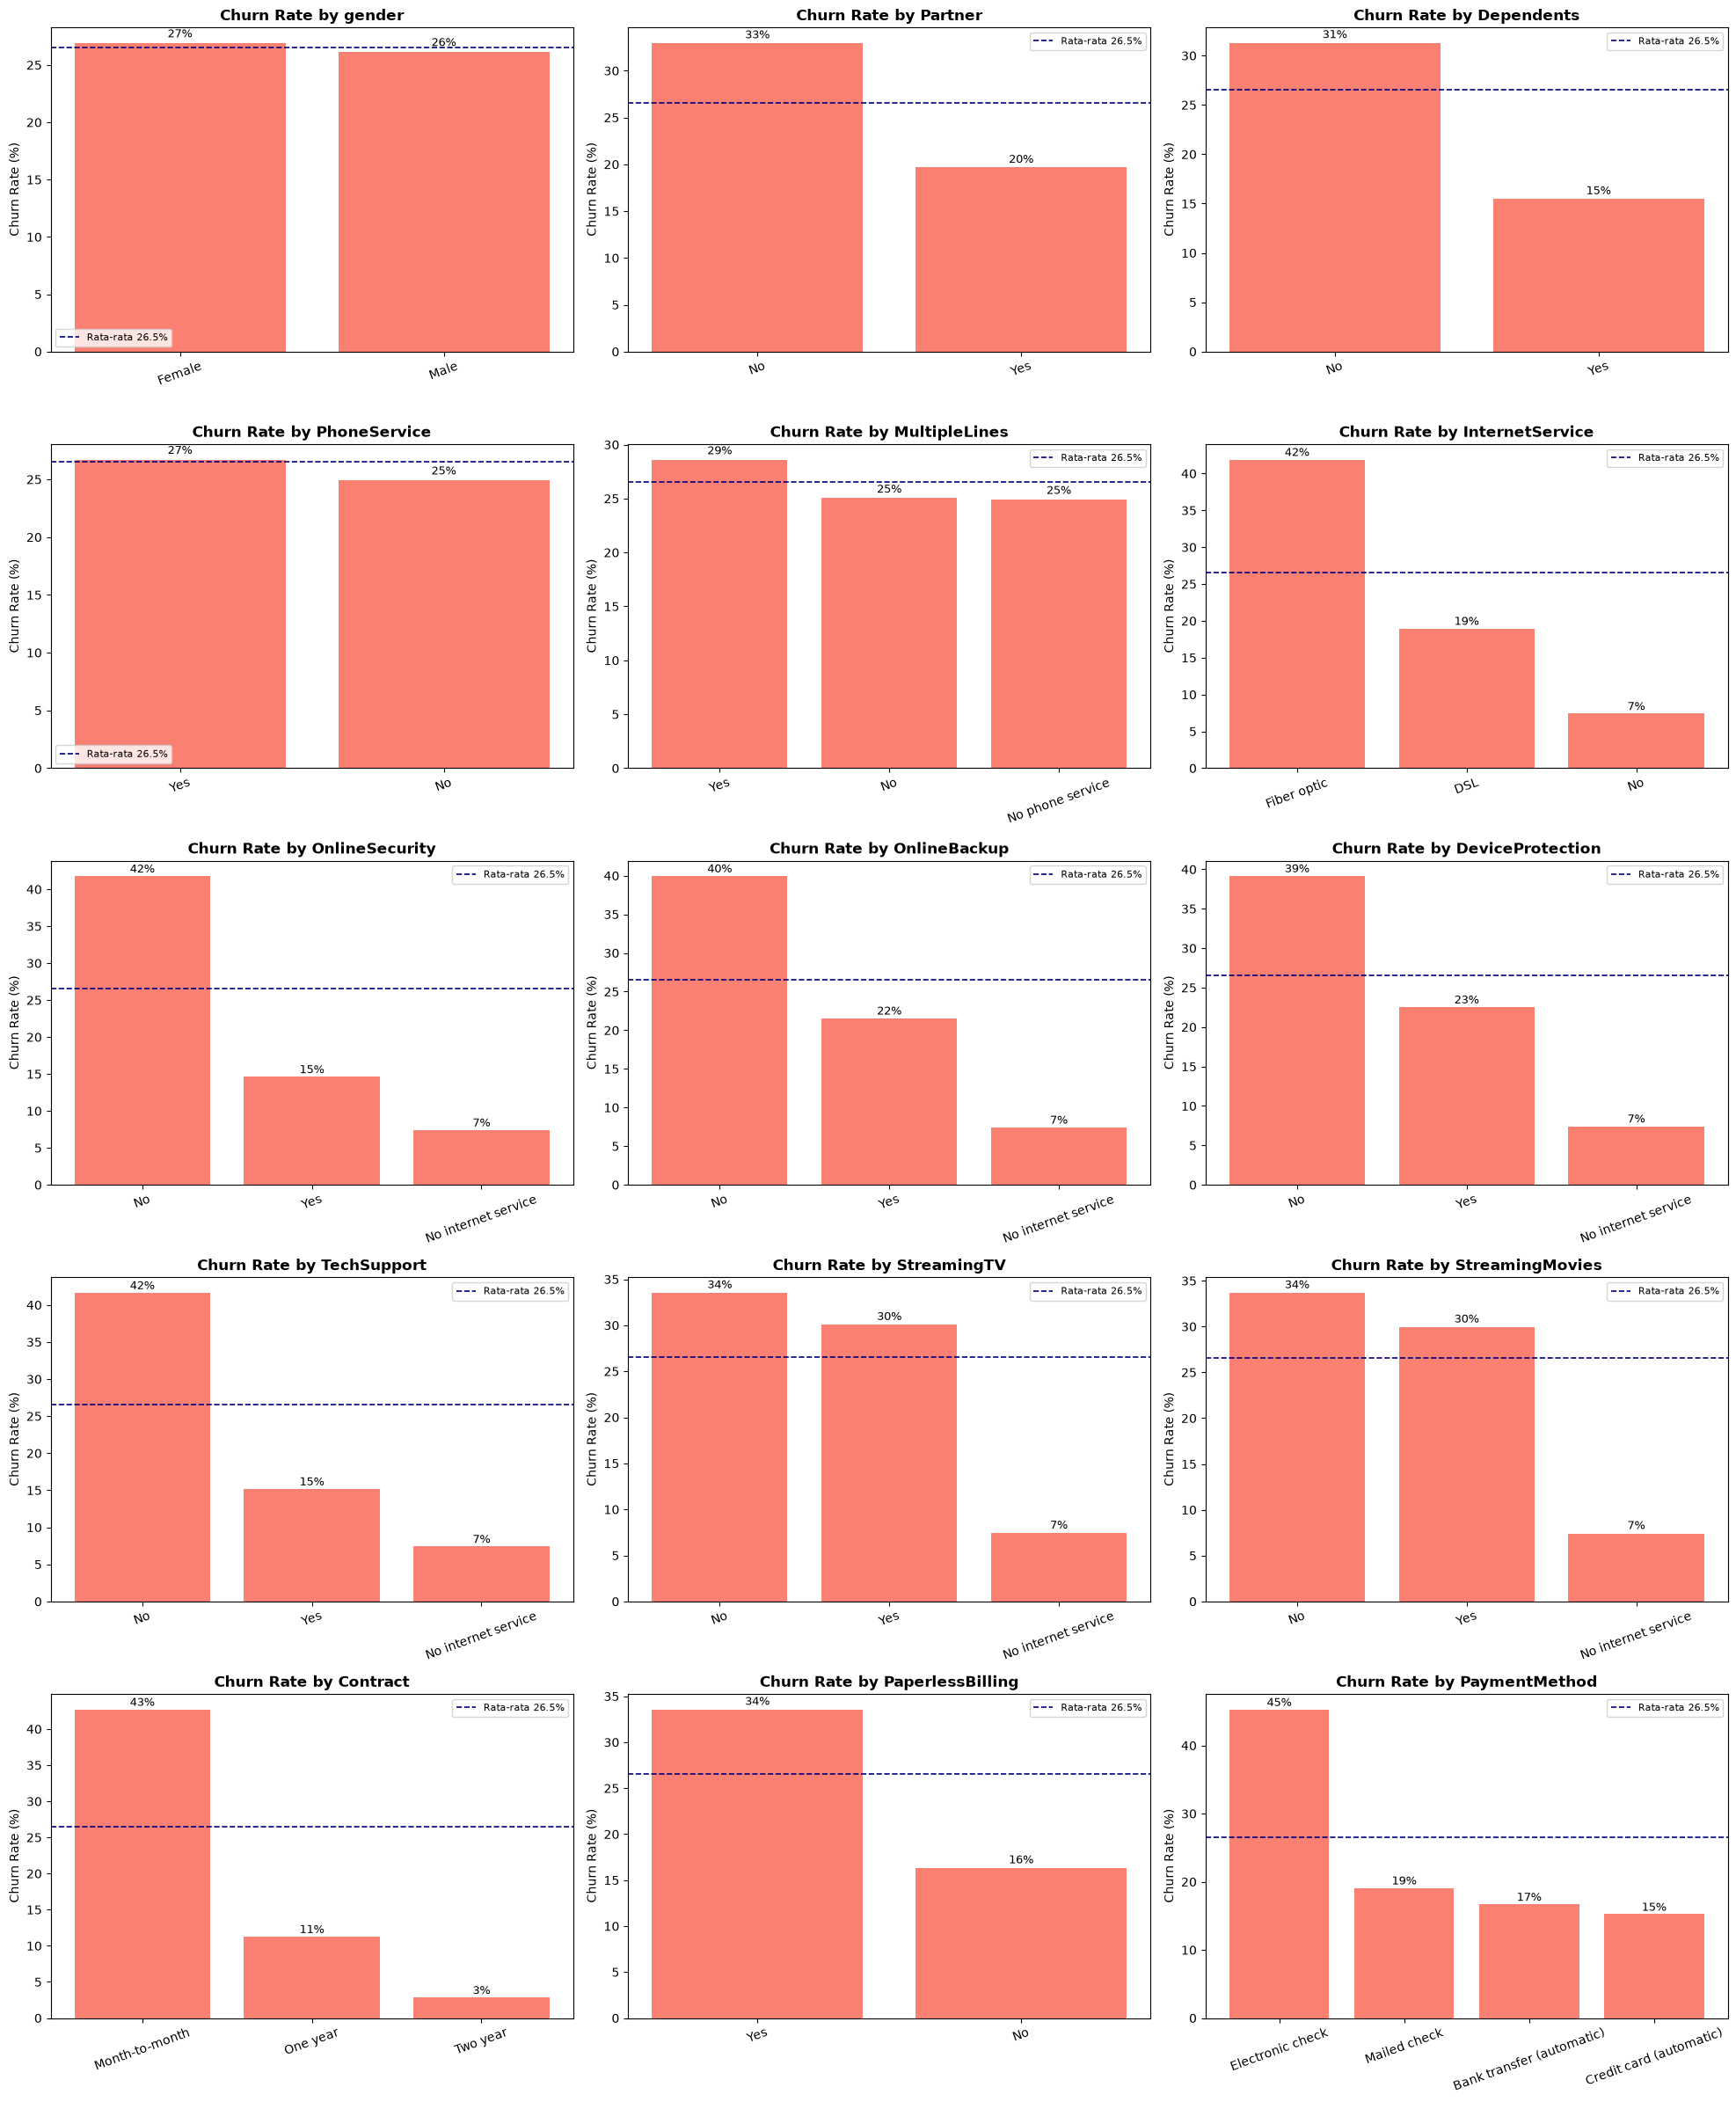

In [11]:
# Churn rate per kategori untuk SEMUA fitur kategorikal
cat_features = [c for c in categorical_cols if c != 'Churn']
overall_churn = (df['Churn'] == 'Yes').mean() * 100

fig, axes = plt.subplots(5, 3, figsize=(20, 24))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    rate = (df.groupby(col)['Churn']
              .apply(lambda x: (x == 'Yes').mean() * 100)
              .sort_values(ascending=False))

    bars = axes[i].bar(rate.index.astype(str), rate.values, color='salmon')
    axes[i].axhline(overall_churn, color='navy', linestyle='--', linewidth=1.2,
                    label=f'Rata-rata {overall_churn:.1f}%')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].legend(fontsize=8)
    for b in bars:
        axes[i].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                     f'{b.get_height():.0f}%', ha='center', fontsize=9)

# matikan subplot sisa
for j in range(len(cat_features), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('../figures/churn_by_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

### 📌 Insight Kategorikal

**Pendorong churn terkuat** (garis putus-putus navy = rata-rata 26.5%):
- **Contract → Month-to-month: 42.7%** vs Two year **2.8%** 
- **PaymentMethod → Electronic check: 45.3%** vs metode otomatis ~15–17%.
- **InternetService → Fiber optic: 41.9%** vs DSL 19% vs No internet 7.4%.
- **Tanpa add-on** (OnlineSecurity 41.8%, TechSupport 41.6%) jauh lebih tinggi dari yang punya (~15%).
- **Tanpa Partner (33%)** & **tanpa Dependents (31%)** lebih rawan.

**Hampir tidak berpengaruh (kandidat di-drop):**
- **gender**: 26.9% vs 26.2% → nyaris sama.
- **PhoneService**: 26.7% vs 24.9%.

> Catatan: kategori `No internet service` selalu 7.4% di banyak fitur add-on karena merepresentasikan kelompok pelanggan yang sama (tidak punya internet) — ini akan jadi pertimbangan saat encoding.

# 📈 Fitur Numerikal vs Churn

Membandingkan distribusi `tenure`, `MonthlyCharges`, dan `TotalCharges` antara pelanggan yang churn vs tidak — untuk melihat fitur numerikal mana yang membedakan kedua kelompok.

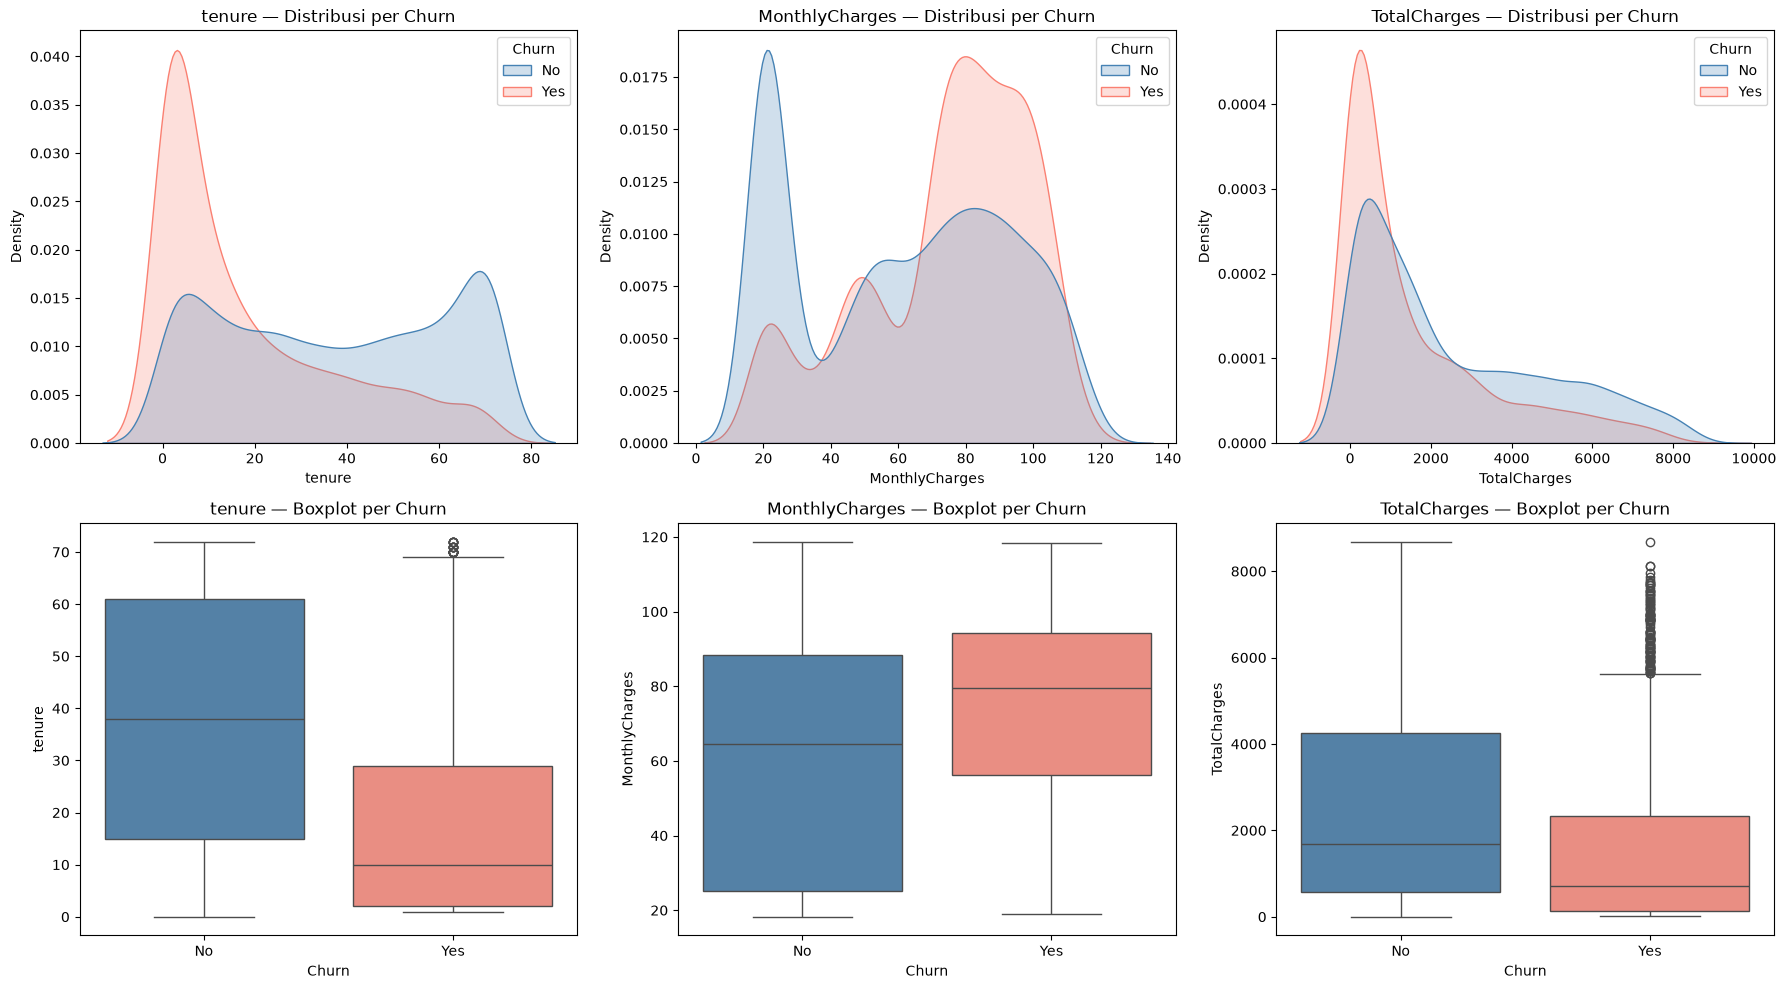

Rata-rata fitur numerikal per status Churn:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       37.6            61.3        2549.9
Yes      18.0            74.4        1531.8


In [12]:
# Distribusi fitur numerikal dibandingkan antara churn vs tidak
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
palette = {'No': 'steelblue', 'Yes': 'salmon'}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(num_features):
    # KDE: bentuk distribusi per kelas (common_norm=False agar tiap kelas dinormalisasi sendiri)
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False,
                palette=palette, ax=axes[0, i])
    axes[0, i].set_title(f'{col} — Distribusi per Churn')

    # Boxplot: bandingkan median & sebaran
    sns.boxplot(data=df, x='Churn', y=col, hue='Churn', palette=palette,
                legend=False, ax=axes[1, i])
    axes[1, i].set_title(f'{col} — Boxplot per Churn')

plt.tight_layout()
plt.savefig('../figures/numerical_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# Rata-rata per kelas
print("Rata-rata fitur numerikal per status Churn:")
print(df.groupby('Churn')[num_features].mean().round(1).to_string())

### 📌 Insight Numerikal vs Churn

| Fitur | Rata-rata (Churn = No) | Rata-rata (Churn = Yes) | Arah |
|---|---|---|---|
| **tenure** | 37.6 bulan | **18.0 bulan** | 🔴 Pelanggan baru jauh lebih rawan churn |
| **MonthlyCharges** | Rp 61.300 | **Rp 74.400** | 🔴 Tagihan bulanan tinggi → churn naik |
| **TotalCharges** | Rp 2.549.900 | Rp 1.531.800 | 🔵 Rendah karena tenure pendek (akumulasi singkat) |

**Kesimpulan:** Pelanggan yang **baru bergabung** + **bayar mahal per bulan** = kombinasi paling berisiko. `TotalCharges` rendah pada churner bukan penyebab, tapi konsekuensi dari tenure yang pendek — sehingga `tenure` dan `TotalCharges` saling berkorelasi kuat (hati-hati multikolinearitas saat modeling).

# 🔗 Korelasi Fitur dengan Churn

Fitur kategorikal di-encode dulu (binary 0/1 + one-hot) supaya bisa dihitung korelasinya terhadap Churn. Bar merah = mendorong churn, biru = menahan churn.

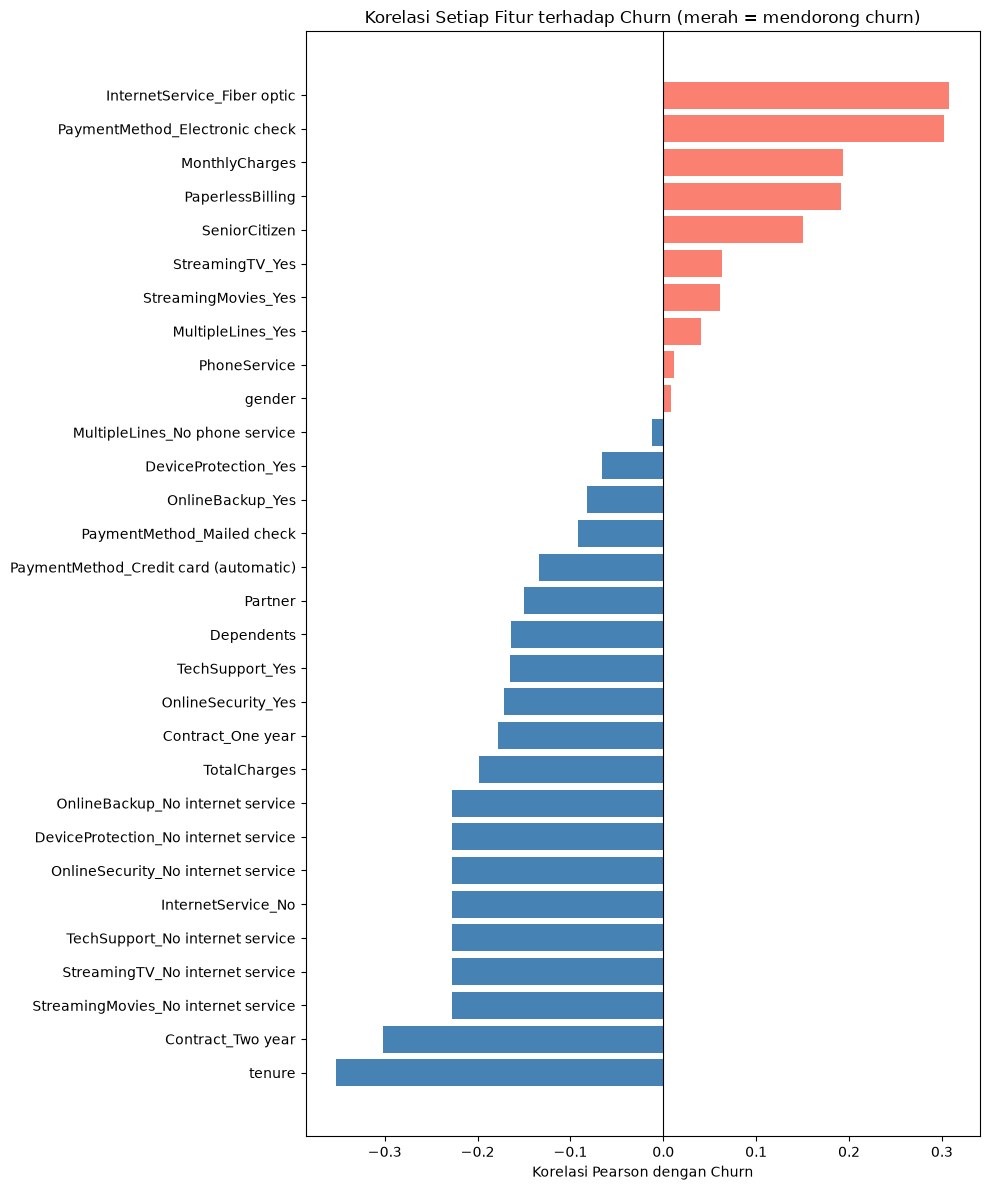

Top 8 PENDORONG churn (korelasi +):
InternetService_Fiber optic       0.308
PaymentMethod_Electronic check    0.302
MonthlyCharges                    0.193
PaperlessBilling                  0.192
SeniorCitizen                     0.151
StreamingTV_Yes                   0.063
StreamingMovies_Yes               0.061
MultipleLines_Yes                 0.040

Top 8 PENAHAN churn (korelasi -):
tenure                                 -0.352
Contract_Two year                      -0.302
StreamingMovies_No internet service    -0.228
StreamingTV_No internet service        -0.228
TechSupport_No internet service        -0.228
InternetService_No                     -0.228
OnlineSecurity_No internet service     -0.228
DeviceProtection_No internet service   -0.228


In [13]:
# Encode fitur untuk analisis korelasi terhadap Churn
df_enc = df.copy()
df_enc['Churn'] = (df_enc['Churn'] == 'Yes').astype(int)

# Binary kategorikal -> 0/1
binary_map = {'Yes': 1, 'No': 0, 'Female': 1, 'Male': 0}
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'gender']:
    df_enc[col] = df_enc[col].map(binary_map)

# One-hot untuk fitur multi-kategori
multi_cat = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
             'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
             'Contract', 'PaymentMethod']
df_enc = pd.get_dummies(df_enc, columns=multi_cat, drop_first=True)
df_enc = df_enc.drop(columns=['customerID'])

# Korelasi setiap fitur terhadap Churn
corr_churn = df_enc.corr(numeric_only=True)['Churn'].drop('Churn').sort_values()

plt.figure(figsize=(10, 12))
colors = ['steelblue' if v < 0 else 'salmon' for v in corr_churn.values]
plt.barh(corr_churn.index, corr_churn.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Korelasi Setiap Fitur terhadap Churn (merah = mendorong churn)')
plt.xlabel('Korelasi Pearson dengan Churn')
plt.tight_layout()
plt.savefig('../figures/correlation_with_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 8 PENDORONG churn (korelasi +):')
print(corr_churn.sort_values(ascending=False).head(8).round(3).to_string())
print('\nTop 8 PENAHAN churn (korelasi -):')
print(corr_churn.head(8).round(3).to_string())

# 📝 Ringkasan Insight Utama & Implikasi Bisnis

## Profil Pelanggan Paling Rawan Churn
Berdasarkan analisis, churn paling tinggi terjadi pada pelanggan dengan ciri:

| Faktor | Kategori Berisiko | Churn Rate | Avg = 26.5% |
|---|---|---|---|
| **Contract** | Month-to-month | **42.7%** | 🔴 vs Two year 2.8% |
| **PaymentMethod** | Electronic check | **45.3%** | 🔴 vs auto-payment ~16% |
| **InternetService** | Fiber optic | **41.9%** | 🔴 vs DSL 19% |
| **Tenure** | Pelanggan baru (~18 bln) | tinggi | 🔴 vs loyal (~38 bln) |
| **OnlineSecurity** | Tidak punya | **41.8%** | 🔴 vs punya 14.6% |
| **TechSupport** | Tidak punya | **41.6%** | 🔴 vs punya 15.2% |
| **Partner/Dependents** | Sendiri (tanpa keluarga) | 31–33% | 🔴 |

## Faktor yang TIDAK berpengaruh
- **gender** (26.9% vs 26.2%) → hampir identik, bisa di-drop
- **PhoneService** (26.7% vs 24.9%) → pengaruh kecil

## 💡 Implikasi Bisnis (Telkomsel)
1. **Kontrak adalah senjata retensi terkuat.** Selisih churn Month-to-month (42.7%) vs Two year (2.8%) = ~15x. → Dorong pelanggan ke kontrak tahunan via diskon.
2. **Pelanggan Fiber optic mahal & rawan.** Tarif tinggi (MonthlyCharges churner Rp74rb vs Rp61rb) tapi churn tinggi → indikasi ekspektasi kualitas tidak terpenuhi. Perlu audit kualitas layanan.
3. **Bundling add-on menahan churn.** OnlineSecurity & TechSupport memangkas churn dari ~42% ke ~15%. → Tawarkan paket bundling.
4. **3 bulan pertama kritis.** Churner rata-rata tenure 18 bulan, mayoritas pergi di awal. → Program onboarding & early-warning.
5. **Electronic check = sinyal bahaya.** 45.3% churn. → Arahkan ke pembayaran otomatis (auto-debit).

## ➡️ Next Step (Hari 2: Preprocessing)
- Drop `customerID` (identitas) & pertimbangkan drop `gender`
- Encoding: binary map + one-hot untuk multi-kategori
- Handle imbalance (26.5% churn) → `class_weight` / SMOTE saat modeling
- Feature engineering: kelompok `tenure` (0–12, 13–24, dst), jumlah add-on aktif
- Mulai tracking dengan **MLflow**